# 1. Import thư viện và các bảng dữ liệu

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import StrMethodFormatter

import os

input_dir='datasets/'
output_dir='output/'

orders=pd.read_csv(input_dir+'orders.csv')
order_items=pd.read_csv(input_dir+'order_items.csv')
payments=pd.read_csv(input_dir+'payments.csv')
customers=pd.read_csv(input_dir+'customers.csv')
returns=pd.read_csv(input_dir+'returns.csv')
review=pd.read_csv(input_dir+'reviews.csv')
products=pd.read_csv(input_dir+'products.csv')
geography=pd.read_csv(input_dir+'geography.csv')

# 2. Ghép các bảng với thông tin liên quan lại thành bảng master

In [3]:
master = pd.merge(orders, order_items, on='order_id', how='left')
master = pd.merge(master, payments, on='order_id', how='left')
master = pd.merge(master, customers, on='customer_id', how='left')

master = master.rename(columns={'zip_x': 'zip', 'payment_method_x': 'payment_method'})
master = master.drop(columns=['zip_y', 'payment_method_y'])

master = pd.merge(master, geography, on='zip', how='left')

master = master.rename(columns={'city_y': 'city'})
master = master.drop(columns=['city_x'])

master = pd.merge(master, returns, on=['order_id', 'product_id'], how='left', suffixes=('', '_ret'))
master = pd.merge(master, review, on=['order_id', 'product_id', 'customer_id'], how='left')

In [4]:
master['order_date'] = pd.to_datetime(master['order_date'])
snapshot_date=master['order_date'].max()+dt.timedelta(days=1)

metrics = master.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum',
    'refund_amount': 'sum',
    'rating': 'mean'
}).rename(columns={'order_date': 'recency', 'order_id': 'frequency'})

metrics['net_monetary']=metrics['payment_value']-metrics['refund_amount'].fillna(0)

# 3. Phân tích và đánh giá

## 3.1. Biểu đồ Pareto
Biểu đồ giúp xác định nhóm khách hàng trọng tâm. Từ biểu đồ trên, ta thấy
- Khoảng 20% khách hàng đóng góp vào gần 62% doanh thu
- 80% doanh thu của doanh nghiệp được đóng góp bởi gần 40% khách hàng

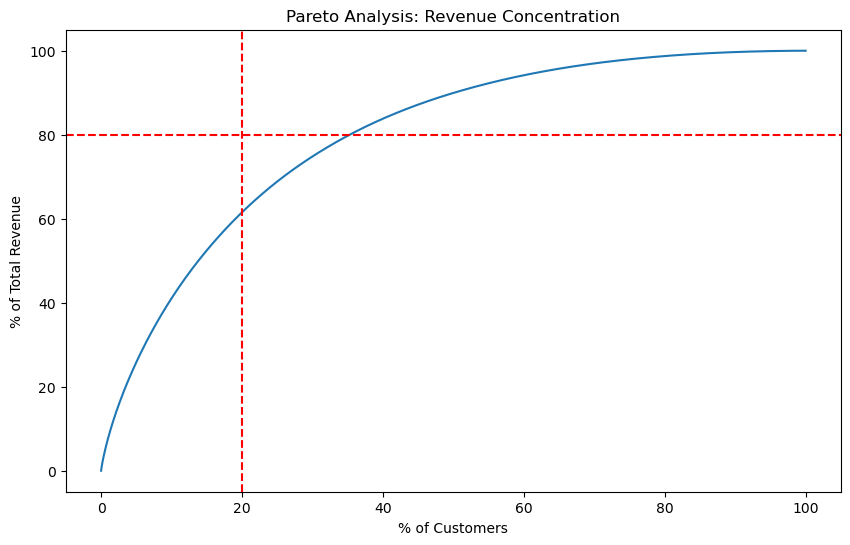

In [26]:
df_pareto = metrics.sort_values('net_monetary', ascending=False)
df_pareto['cum_sum'] = df_pareto['net_monetary'].cumsum()
df_pareto['cum_perc'] = 100 * df_pareto['cum_sum'] / df_pareto['net_monetary'].sum()
df_pareto['cust_perc'] = 100 * (pd.Series(range(1, len(df_pareto) + 1)) / len(df_pareto)).values

plt.figure(figsize=(10, 6))
sns.lineplot(x='cust_perc', y='cum_perc', data=df_pareto)
plt.axhline(80, color='r', linestyle='--')
plt.axvline(20, color='r', linestyle='--')
plt.title('Pareto Analysis: Revenue Concentration')
plt.xlabel('% of Customers')
plt.ylabel('% of Total Revenue')
plt.savefig(output_dir+"pareto_chart.png", dpi=300, bbox_inches='tight')
plt.show()

## 3.2. Phân tích top 10 khách hàng chi trả nhiều nhất

   customer_id       city  net_monetary    rating
0        13699     Phu Ly    4647414.45  4.750000
1        13698     Phu Ly    4327202.85  3.777778
2        13697     Phu Ly    3650062.00  3.714286
3        13701     Phu Ly    3615319.60  4.454545
4       139815   Vung Tau    3248920.64  4.000000
5       139816   Vung Tau    3157488.64  4.000000
6        13700     Phu Ly    3112370.66  4.250000
7       139814   Vung Tau    3101396.29  3.071429
8       139813   Vung Tau    3005023.63  3.785714
9        22450  Hai Phong    2819189.04  3.750000


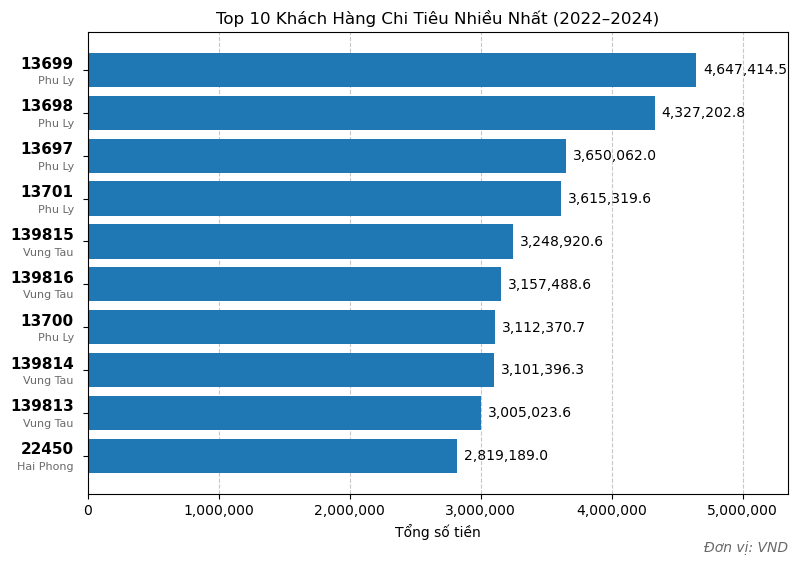

In [36]:
ranked=metrics.sort_values('net_monetary', ascending=False)
cutoff_index=int(len(ranked)*0.20)
top_ids = metrics.sort_values('net_monetary', ascending=False).head(cutoff_index).index
metrics['is_hvc'] = metrics.index.isin(top_ids)

vip_list=ranked.head(cutoff_index).copy()
final_hvc_report=pd.merge(vip_list, customers, on='customer_id')
final_hvc_report=pd.merge(final_hvc_report, geography, on='zip')
final_hvc_report=final_hvc_report.drop(columns=['city_y'])
final_hvc_report=final_hvc_report.rename(columns={'city_x': 'city'})

print(final_hvc_report[['customer_id', 'city', 'net_monetary', 'rating']].head(10))

top10 = final_hvc_report[['customer_id', 'net_monetary', 'city']].head(10)

fig, ax = plt.subplots(figsize=(10, 6))

plt.subplots_adjust(left=0.2) 

y_positions = range(len(top10))
bars = ax.barh(y_positions, top10['net_monetary'])

ax.set_yticks(y_positions)
ax.set_yticklabels([]) 

for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(-0.02, i - 0.15, str(row['customer_id']), 
            transform=ax.get_yaxis_transform(), 
            ha='right', va='center', fontsize=11, fontweight='bold')
    
    ax.text(-0.02, i + 0.25, row['city'], 
            transform=ax.get_yaxis_transform(), 
            ha='right', va='center', fontsize=8, color='dimgray')

ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.bar_label(bars, fmt='{:,.1f}', padding=5)

ax.grid(True, axis='x', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

ax.set_xlabel('Tổng số tiền')
ax.set_title('Top 10 Khách Hàng Chi Tiêu Nhiều Nhất (2022–2024)')

ax.text(
    1.0, -0.1, 'Đơn vị: VND',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=10,
    fontstyle='italic',
    color='dimgray'
)

ax.invert_yaxis() 

ax.set_xlim(right=top10['net_monetary'].max() * 1.15) 
plt.savefig(output_dir+"top_10_monetary.png", dpi=300, bbox_inches='tight')
plt.show()

## 3.3. So sánh giữa phần trăm khách hàng và phần trăm doanh thu

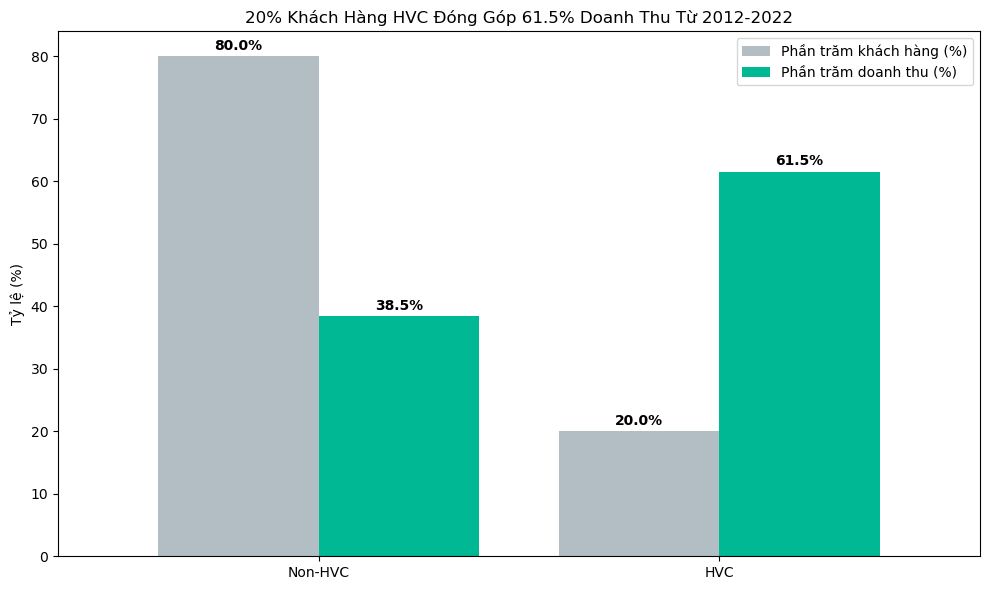

In [28]:
hvc_flat = metrics.reset_index()

gap_data = hvc_flat.groupby('is_hvc').agg({
    'customer_id': 'count',      # Now this column exists!
    'net_monetary': 'sum'
}).rename(columns={'customer_id': 'Customer_Count', 'net_monetary': 'Total_Revenue'})

gap_perc = gap_data.div(gap_data.sum(), axis=1) * 100
gap_perc.index = ['Non-HVC', 'HVC']

ax = gap_perc.plot(kind='bar', figsize=(10, 6), width=0.8, color=['#b2bec3', '#00b894'])

plt.title('20% Khách Hàng HVC Đóng Góp 61.5% Doanh Thu Từ 2012-2022')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(rotation=0)
plt.legend(['Phần trăm khách hàng (%)', 'Phần trăm doanh thu (%)'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 1), 
                ha='center', weight='bold')

plt.tight_layout()
plt.savefig(output_dir+"hvc_pareto.png", dpi=300, bbox_inches='tight')
plt.show()

## 3.4. Phân tích tỉ lệ các khách hàng tiềm năng (HVC) qua các kênh tiếp cận, giới tính và độ tuổi

Missing Acquisition Channels: 0
                     Standard_Cust  HVC_Cust  HVC_Rate_%
acquisition_channel                                     
Tìm kiếm trả phí             20654      3631   14.951616
Mạng Xã hội                  20817      3631   14.851931
Tìm kiếm tự nhiên            31045      5405   14.828532
Truy cập trực tiếp            8352      1451   14.801591
Email                        12509      2165   14.753987
Qua giới thiệu               10504      1766   14.392828


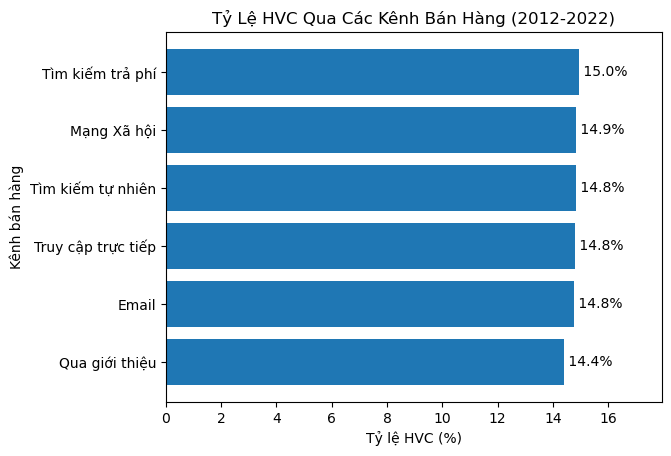

In [37]:
full_profile = pd.merge(customers, metrics[['is_hvc']], on='customer_id', how='left')
full_profile['is_hvc'] = (
    full_profile['is_hvc']
    .astype('boolean')
    .fillna(False)
)

print(f"Missing Acquisition Channels: {full_profile['acquisition_channel'].isna().sum()}")

channel_analysis = full_profile.pivot_table(
    index='acquisition_channel', 
    columns='is_hvc', 
    values='customer_id', 
    aggfunc='count', 
    fill_value=0
)

channel_analysis.columns = ['Standard_Cust', 'HVC_Cust']
channel_analysis['HVC_Rate_%'] = (channel_analysis['HVC_Cust'] / (channel_analysis['HVC_Cust'] + channel_analysis['Standard_Cust'])) * 100

channel_mapping = {
    'paid_search': 'Tìm kiếm trả phí',
    'social_media': 'Mạng Xã hội',
    'organic_search': 'Tìm kiếm tự nhiên',
    'direct': 'Truy cập trực tiếp',
    'email_campaign': 'Email',
    'referral': 'Qua giới thiệu'
}

channel_analysis = channel_analysis.rename(index=channel_mapping)

print(channel_analysis.sort_values('HVC_Rate_%', ascending=False))

channel_sorted = channel_analysis.sort_values('HVC_Rate_%', ascending=True)

plt.figure()
plt.barh(channel_sorted.index, channel_sorted['HVC_Rate_%'])

plt.xlabel('Tỷ lệ HVC (%)')
plt.ylabel('Kênh bán hàng')
plt.title('Tỷ Lệ HVC Qua Các Kênh Bán Hàng (2012-2022)')
max_val = channel_sorted['HVC_Rate_%'].max()
plt.xlim(0, max_val * 1.2)
# Add labels
for i, v in enumerate(channel_sorted['HVC_Rate_%']):
    plt.text(v, i, f" {v:.1f}%", va='center')

plt.savefig(output_dir+"hvc_channel.png", dpi=300, bbox_inches='tight')
plt.show()

--- Age Group Trend ---
           Standard   HVC  HVC_Concentration_%
age_group                                     
25-34         31064  5278            29.242617
35-44         27147  4773            26.444678
45-54         19644  3528            19.546789
18-24         14579  2460            13.629564
55+           11447  2010            11.136351

--- Gender Trend ---
              Standard   HVC  HVC_Rate
gender                                
Nữ               50847  8793  0.147435
Nam              48906  8551  0.148824
Phi nhị giới      4128   705  0.145872


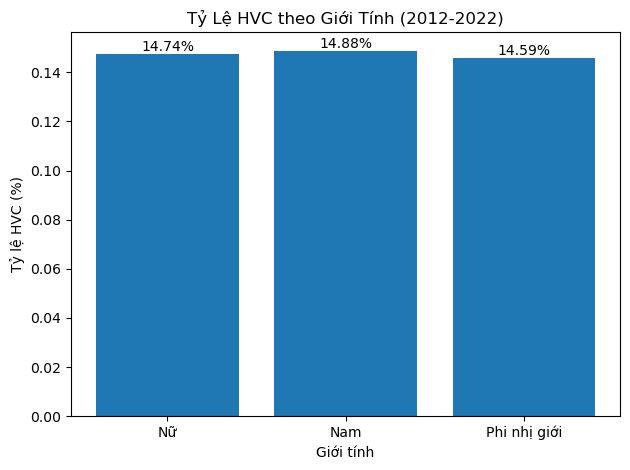

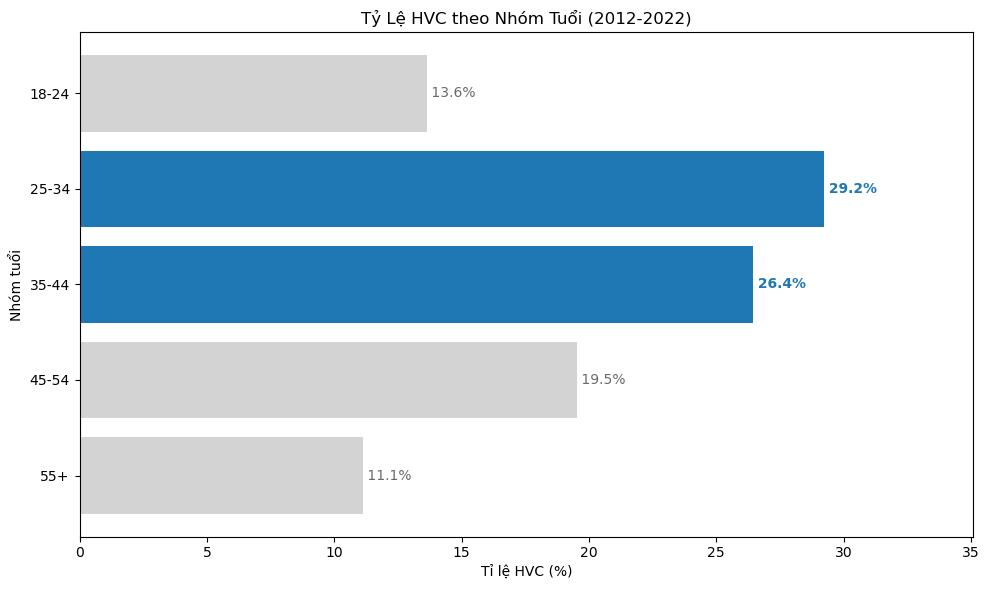

In [38]:
age_analysis = full_profile.pivot_table(
    index='age_group',
    columns='is_hvc',
    values='customer_id',
    aggfunc='count',
    fill_value=0
)
age_analysis.columns = ['Standard', 'HVC']
age_analysis['HVC_Concentration_%'] = (age_analysis['HVC'] / age_analysis['HVC'].sum()) * 100
gender_analysis = full_profile.pivot_table(
    index='gender', 
    columns='is_hvc', 
    values='customer_id', 
    aggfunc='count', 
    fill_value=0
)
gender_analysis.columns = ['Standard', 'HVC']
gender_analysis['HVC_Rate'] = gender_analysis['HVC'] / (gender_analysis['HVC'] + gender_analysis['Standard'])
gender_mapping = {
    'Male' : 'Nam',
    'Female': 'Nữ',
    'Non-binary': 'Phi nhị giới'
}

gender_analysis = gender_analysis.rename(index=gender_mapping)


print("--- Age Group Trend ---")
print(age_analysis.sort_values('HVC_Concentration_%', ascending=False))
print("\n--- Gender Trend ---")
print(gender_analysis)

gender_plot = gender_analysis.copy()

plt.figure()
plt.bar(gender_plot.index.astype(str), gender_plot['HVC_Rate'])

plt.xlabel('Giới tính')
plt.ylabel('Tỷ lệ HVC (%)')
plt.title('Tỷ Lệ HVC theo Giới Tính (2012-2022)')

for i, v in enumerate(gender_plot['HVC_Rate']):
    plt.text(i, v, f"{v:.2%}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
age_plot = age_analysis.reindex(age_order)

top_2_threshold = age_plot['HVC_Concentration_%'].nlargest(2).min()

colors = ['#1f77b4' if v >= top_2_threshold else 'lightgray' for v in age_plot['HVC_Concentration_%']]

plt.figure(figsize=(10, 6))

bars = plt.barh(age_plot.index.astype(str), age_plot['HVC_Concentration_%'], color=colors)

plt.xlabel('Tỉ lệ HVC (%)')
plt.ylabel('Nhóm tuổi')
plt.title('Tỷ Lệ HVC theo Nhóm Tuổi (2012-2022)')

max_val = age_plot['HVC_Concentration_%'].max()
plt.xlim(0, max_val * 1.2)
plt.gca().invert_yaxis()

for i, v in enumerate(age_plot['HVC_Concentration_%']):
    text_color = '#1f77b4' if v >= top_2_threshold else 'dimgray'
    plt.text(v, i, f" {v:.1f}%", va='center', color=text_color, 
             fontweight='bold' if v >= top_2_threshold else 'normal')

plt.tight_layout()
plt.savefig(output_dir+"hvc_gender.png", dpi=300, bbox_inches='tight')
plt.savefig(output_dir+"hvc_cohort.png", dpi=300, bbox_inches='tight')
plt.show()

## 3.5. Phân tích mật độ HVC và thị trường theo thành phố


--- Top Cities by HVC Density ---
                  HVC_Count  Total_Cust  HVC_Density_%
city_x                                                
Pleiku                  362        1253      28.890662
Ho Chi Minh City        387        1359      28.476821
Vung Tau                349        1251      27.897682
Bac Lieu                329        1211       27.16763
Buon Ma Thuot           309        1167      26.478149
Long Xuyen              309        1194      25.879397
Ben Tre                 304        1179      25.784563
Tra Vinh                273        1138      23.989455
Soc Trang               289        1208      23.923841
Vinh Long               318        1336      23.802395


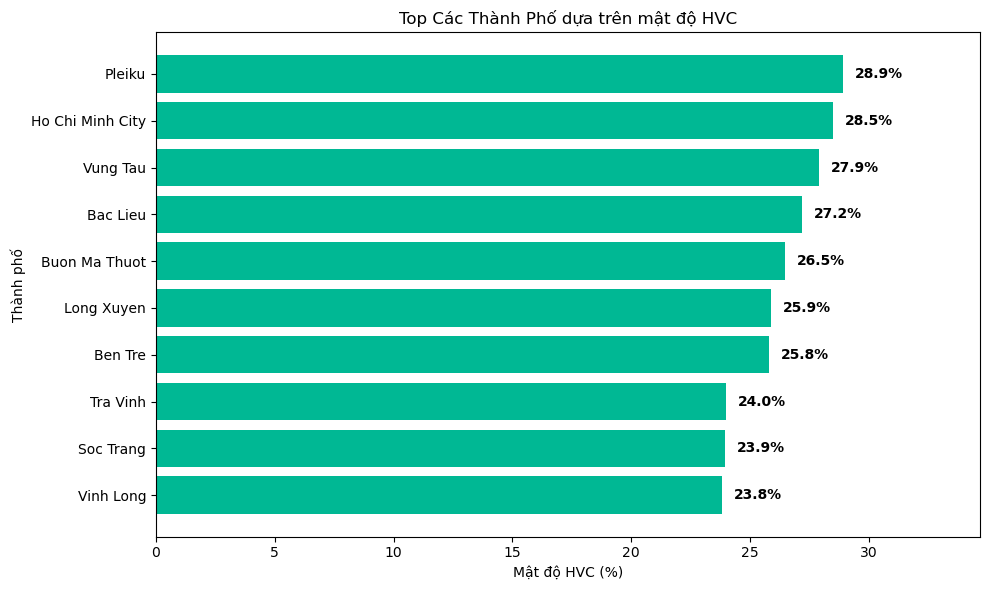

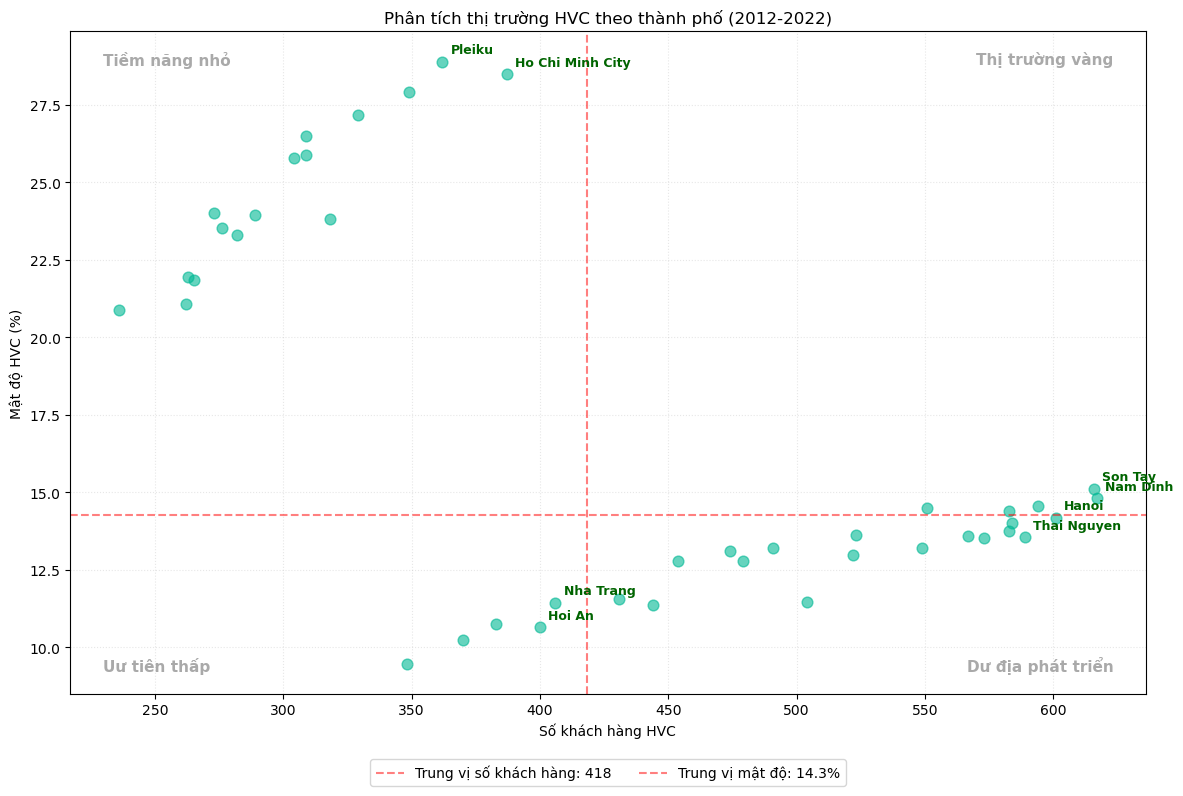

In [40]:
geo_profile=pd.merge(full_profile, geography, on='zip')
city_hvc_trend=geo_profile.groupby('city_x').agg({
    'is_hvc': 'sum',
    'customer_id': 'count'
}).rename(columns={'is_hvc': 'HVC_Count', 'customer_id': 'Total_Cust'})

city_hvc_trend['HVC_Density_%']=(city_hvc_trend['HVC_Count'])/(city_hvc_trend['Total_Cust'])*100
print("\n--- Top Cities by HVC Density ---")
print(city_hvc_trend.sort_values('HVC_Density_%', ascending=False).head(10))

top_cities = city_hvc_trend.sort_values('HVC_Density_%', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_cities.index.astype(str), top_cities['HVC_Density_%'], color='#00b894')

plt.gca().invert_yaxis() 

plt.xlabel('Mật độ HVC (%)')
plt.ylabel('Thành phố')
plt.title('Top Các Thành Phố dựa trên mật độ HVC')

max_val = city_hvc_trend['HVC_Density_%'].max()
plt.xlim(0, max_val * 1.2)

for i, v in enumerate(top_cities['HVC_Density_%']):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir+"hvc_city_density.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 8))
plt.scatter(city_hvc_trend['HVC_Count'], city_hvc_trend['HVC_Density_%'], alpha=0.6, color='#00b894', s=60)
plt.xlabel('Số khách hàng HVC')
plt.ylabel('Mật độ HVC (%)')
plt.title('Phân tích thị trường HVC theo thành phố (2012-2022)')

median_count = city_hvc_trend['HVC_Count'].median()
median_density = city_hvc_trend['HVC_Density_%'].median()

min_x, max_x = plt.xlim()
min_y, max_y = plt.ylim()

plt.axvline(x=median_count, color='red', linestyle='--', alpha=0.5, label=f'Trung vị số khách hàng: {median_count:.0f}')
plt.axhline(y=median_density, color='red', linestyle='--', alpha=0.5, label=f'Trung vị mật độ: {median_density:.1f}%')

offset_x = (max_x - min_x) * 0.03
offset_y = (max_y - min_y) * 0.03

plt.text(min_x + offset_x, max_y - offset_y,
         'Tiềm năng nhỏ', color='darkgrey', fontsize=11, fontweight='bold', ha='left', va='top')
plt.text(max_x - offset_x, max_y - offset_y,
         'Thị trường vàng', color='darkgrey', fontsize=11, fontweight='bold', ha='right', va='top')
plt.text(max_x - offset_x, min_y + offset_y,
         'Dư địa phát triển', color='darkgrey', fontsize=11, fontweight='bold', ha='right', va='bottom')
plt.text(min_x + offset_x, min_y + offset_y,
         'Uư tiên thấp', color='darkgrey', fontsize=11, fontweight='bold', ha='left', va='bottom')

high_density = city_hvc_trend['HVC_Density_%'] > median_density
high_count   = city_hvc_trend['HVC_Count']     > median_count

quadrants = {
    'Golden':       (city_hvc_trend[ high_density &  high_count], 'darkgreen', 'HVC_Density_%'),
    'Potential':    (city_hvc_trend[ high_density & ~high_count], 'darkgreen',      'HVC_Density_%'),
    'Growth':       (city_hvc_trend[~high_density &  high_count], 'darkgreen',    'HVC_Count'),
    'Low Priority': (city_hvc_trend[~high_density & ~high_count], 'darkgreen',       'HVC_Count'),
}

for label, (df, color, sort_col) in quadrants.items():
    if not df.empty:
        top_cities = df.nlargest(2, sort_col)
        for idx, row in top_cities.iterrows():
            plt.annotate(
                idx,
                (row['HVC_Count'], row['HVC_Density_%']),
                textcoords="offset points", xytext=(6, 6),
                ha='left', fontsize=9, fontweight='bold', color=color
            )

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.grid(True, which='both', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir + "hvc_city_quadrant_refined.png", dpi=300, bbox_inches='tight')
plt.show()

           city   net_revenue
33      Son Tay  5.762900e+08
22     Nam Dinh  5.694932e+08
35  Thai Nguyen  5.610356e+08
14        Hanoi  5.592942e+08
27       Phu Ly  5.549415e+08
24    Ninh Binh  5.499955e+08
13    Hai Phong  5.443214e+08
12      Ha Long  5.427788e+08
39     Viet Tri  5.402052e+08
0     Bac Giang  5.300077e+08


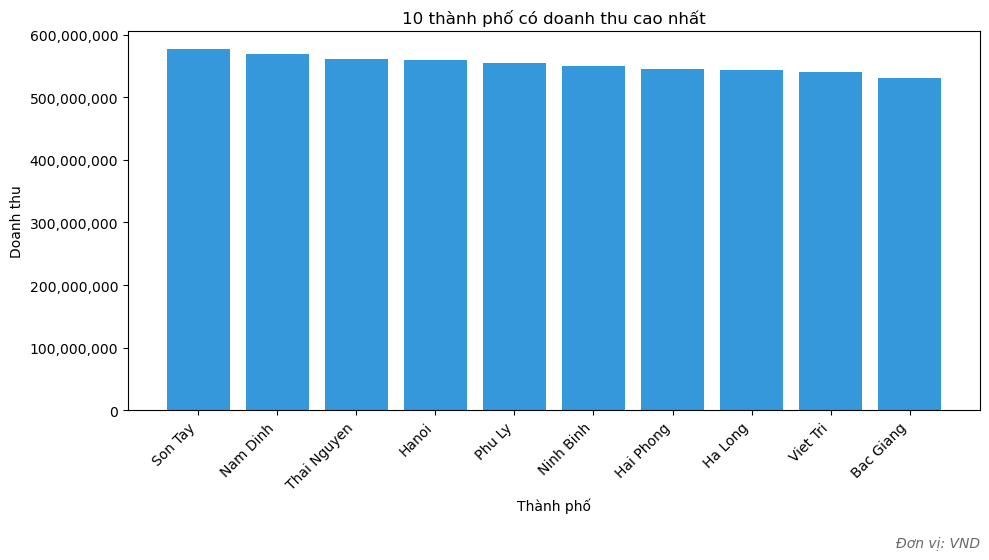

In [32]:
master['net_revenue'] = master['payment_value'] - master['refund_amount'].fillna(0)

city_revenue = master.groupby('city')['net_revenue'].sum().reset_index()

city_revenue = city_revenue.sort_values(by='net_revenue', ascending=False)

print(city_revenue.head(10))

top_cities = city_revenue.head(10)

# Create figure and axis objects for better control
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(top_cities['city'], top_cities['net_revenue'], color='#3498db')

# Labels and title
ax.set_xlabel('Thành phố')
ax.set_ylabel('Doanh thu')
ax.set_title('10 thành phố có doanh thu cao nhất')

# Rotate city names and align them to the right so they look cleaner
plt.xticks(rotation=45, ha='right')

# 1. FIX SCIENTIFIC NOTATION: Format y-axis with commas and no decimals
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.annotate('Đơn vị: VND', xy=(1.0, -0.35), xycoords='axes fraction', 
            ha='right', va='center', fontsize=10, fontstyle='italic', color='dimgray')

# Adjust layout to make room for the rotated text and the bottom-right unit
plt.tight_layout()
plt.show()

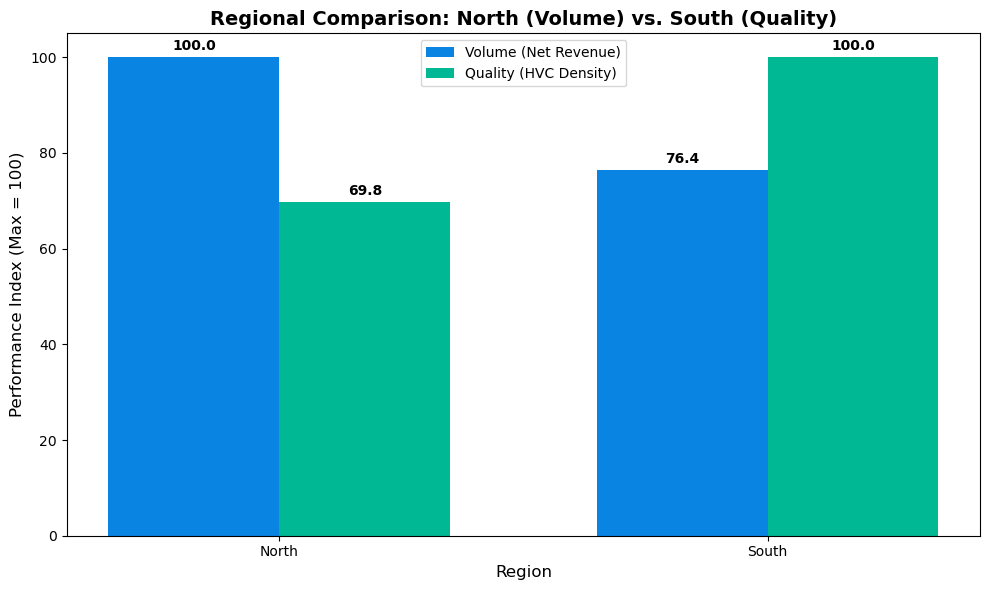

In [33]:
data = {
    'Region': ['North', 'South'],
    'Volume (Avg Revenue)': [550000000, 420000000],  # Representative averages from your top 10
    'Quality (Avg Density %)': [18.5, 26.5]          # Representative averages from your top 10
}

df_comparison = pd.DataFrame(data)

# 2. Normalize data to a 0-100 scale (Indexing) for fair side-by-side comparison
# This allows us to see the 'Trade-off' clearly
df_comparison['Volume_Index'] = (df_comparison['Volume (Avg Revenue)'] / df_comparison['Volume (Avg Revenue)'].max()) * 100
df_comparison['Quality_Index'] = (df_comparison['Quality (Avg Density %)'] / df_comparison['Quality (Avg Density %)'].max()) * 100

# 3. Plotting
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = np.arange(len(df_comparison['Region']))

# Plot bars
bar1 = ax.bar(index, df_comparison['Volume_Index'], bar_width, label='Volume (Net Revenue)', color='#0984e3')
bar2 = ax.bar(index + bar_width, df_comparison['Quality_Index'], bar_width, label='Quality (HVC Density)', color='#00b894')

# Add Labels
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Performance Index (Max = 100)', fontsize=12)
ax.set_title('Regional Comparison: North (Volume) vs. South (Quality)', fontsize=14, fontweight='bold')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(df_comparison['Region'])
ax.legend()

# Adding data labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(bar1)
autolabel(bar2)

plt.tight_layout()
plt.savefig('regional_volume_vs_quality.png')
plt.show()

             Avg_Spend  Median_Spend  Max_Spender  Total_Pop  Skew_Factor
city                                                                     
Pleiku   700556.033149     586389.72   2134089.13        362     1.194694
Son Tay  525388.104026     472923.76   1639778.03        616     1.110936


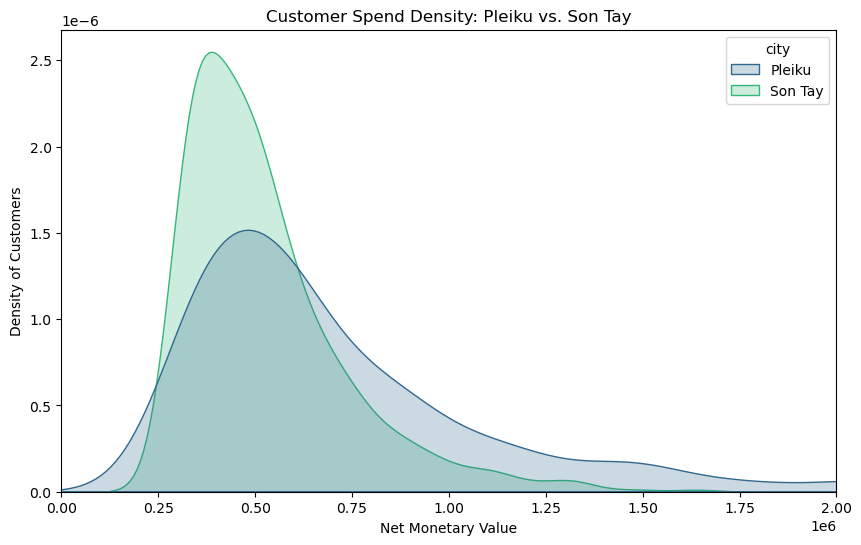

In [34]:
# Aggregate with Median to see the 'True' typical spend
#
city_stats = final_hvc_report.groupby('city').agg({
    'net_monetary': ['mean', 'median', 'max', 'count']
})

# Rename for clarity
city_stats.columns = ['Avg_Spend', 'Median_Spend', 'Max_Spender', 'Total_Pop']

# Look at the 'Skewness' (Difference between Mean and Median)
city_stats['Skew_Factor'] = city_stats['Avg_Spend'] / city_stats['Median_Spend']

print(city_stats.loc[['Pleiku', 'Son Tay']])

compare_df=final_hvc_report[final_hvc_report['city'].isin(['Pleiku', 'Son Tay'])]
plt.figure(figsize=(10, 6))

# KDE Plot shows the 'density' of spend
sns.kdeplot(data=compare_df, x='net_monetary', hue='city', fill=True, common_norm=False, palette='viridis')

plt.title('Customer Spend Density: Pleiku vs. Son Tay')
plt.xlabel('Net Monetary Value')
plt.ylabel('Density of Customers')

# Optional: Limit X-axis to 2M to see the 'Bulk' of the data without the 4.6M outlier squashing it
plt.xlim(0, 2000000) 
plt.show()

In [35]:
fashion_fit = master.merge(full_profile[['customer_id', 'city', 'age_group', 'is_hvc']],
                  on='customer_id',
                  how='left')

fashion_fit = fashion_fit.merge(products[['product_id', 'category', 'segment']],
              on='product_id',
              how='left')
fashion_fit = fashion_fit.drop(columns=['city_y', 'age_group_y'])
fashion_fit  = fashion_fit.rename(columns={'city_x': 'city', 'age_group_x': 'age_group'})

returns_agg = returns.groupby(['order_id', 'product_id'])['return_quantity'].sum().reset_index()


fashion_fit = fashion_fit.merge(returns_agg, on=['order_id', 'product_id'], how='left')
fashion_fit = fashion_fit.drop(columns=['return_quantity_y'])
fashion_fit = fashion_fit.rename(columns={'return_quantity_x' : 'return_quantity'})
fashion_fit['return_quantity'] = fashion_fit['return_quantity'].fillna(0)

target_cities = ['Bac Lieu', 'Buon Ma Thuot', 'Pleiku', 'Ho Chi Minh City', 'Vung Tau']
target_age = ['25-34', '35-44']

southern_hvc_fashion = fashion_fit[
    (fashion_fit['city'].isin(target_cities)) & 
    (fashion_fit['age_group'].isin(target_age)) &
    (fashion_fit['is_hvc'] == True)
]

# 3. Calculate "Affinity Score" (What percentage of their spend goes to which category?)
#
category_affinity = southern_hvc_fashion.groupby(['category', 'segment']).agg({
    'payment_value': 'sum',
    'customer_id': 'nunique'
}).rename(columns={'payment_value': 'Total_Spend', 'customer_id': 'Unique_Buyers'})

# Sort to find the "Winner"
print(category_affinity.sort_values('Total_Spend', ascending=False).head(10))

hvc_category_spend = southern_hvc_fashion.groupby('category').agg({
    'payment_value': 'sum'
}).reset_index()

# Sort descending
hvc_category_spend = hvc_category_spend.sort_values(by='payment_value', ascending=False)

print(hvc_category_spend.head(10))

top_categories = hvc_category_spend.head(10)

# Create figure and axis objects for formatting control
fig, ax = plt.subplots(figsize=(10, 6))

# Create the bar chart and assign it to 'bars' so we can label it later
bars = ax.bar(top_categories['category'], top_categories['payment_value'], color='#8e44ad')

# Labels and title
ax.set_xlabel('Danh mục')
ax.set_ylabel('Tổng chi')
ax.set_title('Nhóm danh mục theo tổng chi của HVC')

# Rotate category names and align them to the right for a clean look
plt.xticks(rotation=45, ha='right')

# 1. FIX THE Y-AXIS FORMAT (e.g., 400M)
# Define a function to divide by 1 million and add 'M'
def millions_formatter(x, pos):
    return f'{x / 1e6:,.0f}M'

ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

# 2. ADD DATA LABELS TO THE HEAD OF EACH BAR
# Create custom string labels for each bar using the same division
custom_labels = [f'{val / 1e6:,.1f}M' for val in top_categories['payment_value']]

# Attach the labels to the bars (padding=3 gives a little space above the bar)
ax.bar_label(bars, labels=custom_labels, padding=3, fontsize=9, color='black')

# Add a little extra space at the top of the chart so the labels don't get cropped
ax.set_ylim(top=top_categories['payment_value'].max() * 1.15)

# 3. UNIT AT BOTTOM RIGHT
# Since 'M' means millions, having 'VND' clarifies the full unit is Millions of VND
ax.annotate('Đơn vị: VND', xy=(1.0, -0.35), xycoords='axes fraction', 
            ha='right', va='center', fontsize=10, fontstyle='italic', color='dimgray')

# Adjust layout
plt.tight_layout()
plt.show()

KeyError: 'is_hvc'

       segment  payment_value
0   Activewear   1.928674e+08
3     Everyday   1.536504e+08
2     Balanced   1.513932e+08
4  Performance   9.644652e+07
5      Premium   2.889564e+07
1  All-weather   2.444212e+07
7       Trendy   1.125239e+07
6     Standard   1.018697e+07


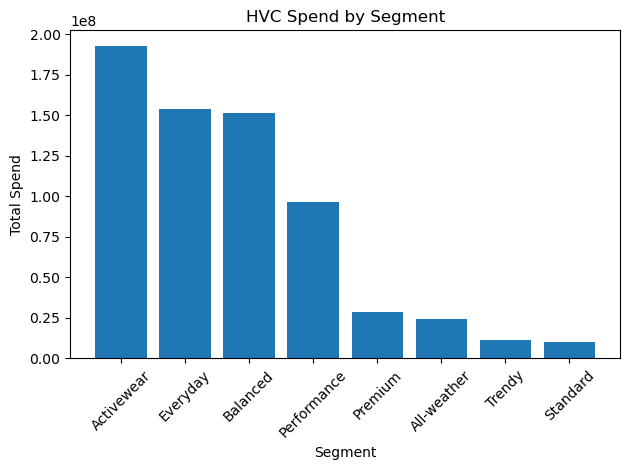

In [ ]:
hvc_segment_spend = southern_hvc_fashion.groupby('segment').agg({
    'payment_value': 'sum'
}).reset_index()

# Sort descending
hvc_segment_spend = hvc_segment_spend.sort_values(by='payment_value', ascending=False)

print(hvc_segment_spend)
plt.figure()
plt.bar(hvc_segment_spend['segment'], hvc_segment_spend['payment_value'])

plt.xlabel('Phân khúc')
plt.ylabel('Tổng chi')
plt.title('Tổng chi của HVC theo phân khúc sản phẩm (2012-2022)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

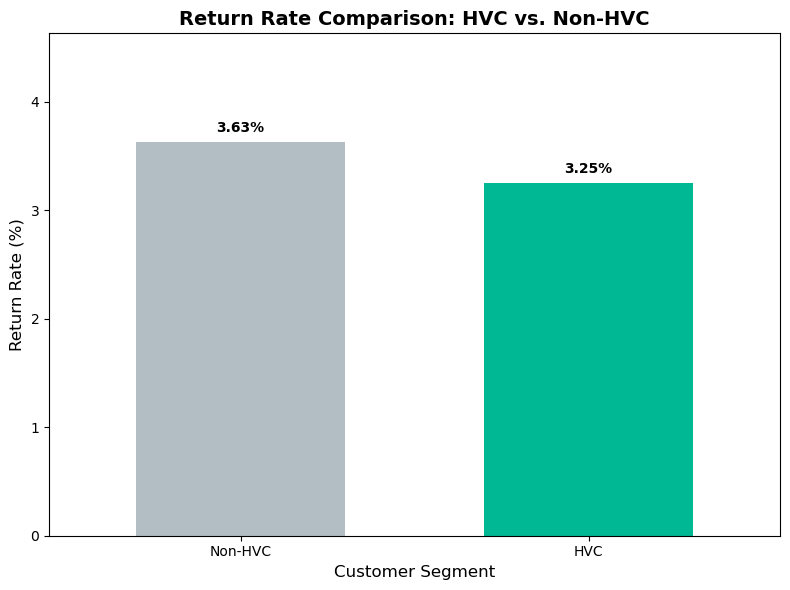

In [ ]:
hvc_lookup = metrics[['is_hvc']].reset_index() 

# 2. Map the flag onto the master table
#
master = pd.merge(master, hvc_lookup, on='customer_id', how='left')

# 3. Fill any NaN values (customers not in the HVC list are False)
master['is_hvc'] = master['is_hvc'].fillna(False)
return_comparison = master.groupby('is_hvc').agg({
    'quantity': 'sum',
    'return_quantity': 'sum'
})

# 2. Calculate the Return Rate Percentage
return_comparison['Return_Rate_%'] = (return_comparison['return_quantity'] / return_comparison['quantity']) * 100
return_comparison.index = ['Non-HVC', 'HVC']

# 3. Create the Side-by-Side Bar Chart
plt.figure(figsize=(8, 6))
colors = ['#b2bec3', '#00b894'] # Grey for non-HVC, Green for HVC
ax = return_comparison['Return_Rate_%'].plot(kind='bar', color=colors, width=0.6)

# Add Labels and Styling
plt.title('Return Rate Comparison: HVC vs. Non-HVC', fontsize=14, fontweight='bold')
plt.ylabel('Return Rate (%)', fontsize=12)
plt.xlabel('Customer Segment', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, max(return_comparison['Return_Rate_%']) + 1) # Add padding for labels

# Add text labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

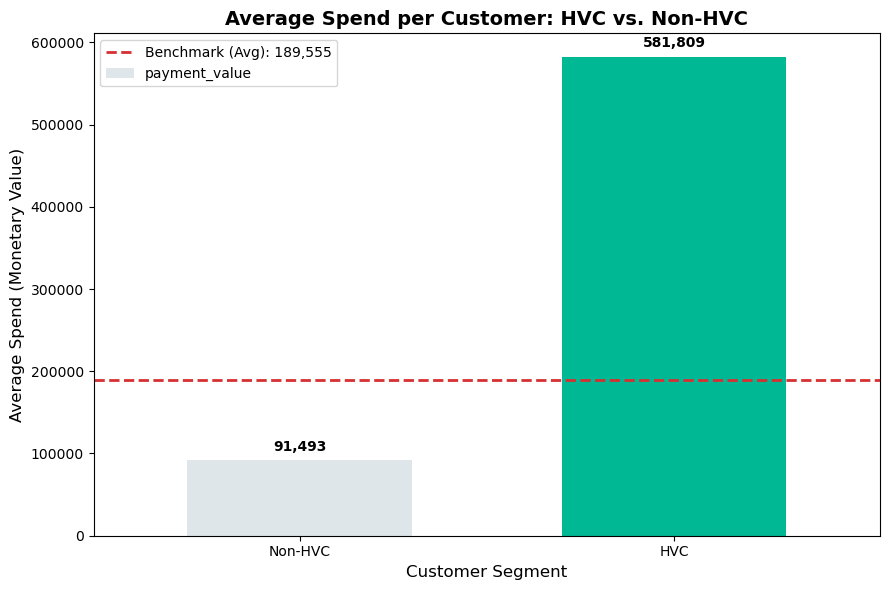

In [ ]:
# 1. Prepare Customer-Level Spend Data
# Assuming 'master' has been merged with 'is_hvc' as discussed
#
customer_spend = master.groupby(['customer_id', 'is_hvc'])['payment_value'].sum().reset_index()

# 2. Calculate Group Averages and the Global Benchmark
#
group_avgs = customer_spend.groupby('is_hvc')['payment_value'].mean()
overall_benchmark = customer_spend['payment_value'].mean()

# Rename index for display
group_avgs.index = ['Non-HVC', 'HVC']

# 3. Create the Bar Chart
plt.figure(figsize=(9, 6))
colors = ['#dfe6e9', '#00b894'] # Light grey and Brand Green
ax = group_avgs.plot(kind='bar', color=colors, width=0.6)

# 4. Add the Benchmark Line
plt.axhline(y=overall_benchmark, color='#d63031', linestyle='--', linewidth=2, label=f'Benchmark (Avg): {overall_benchmark:,.0f}')

# Styling and Labels
plt.title('Average Spend per Customer: HVC vs. Non-HVC', fontsize=14, fontweight='bold')
plt.ylabel('Average Spend (Monetary Value)', fontsize=12)
plt.xlabel('Customer Segment', fontsize=12)
plt.xticks(rotation=0)
plt.legend()

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

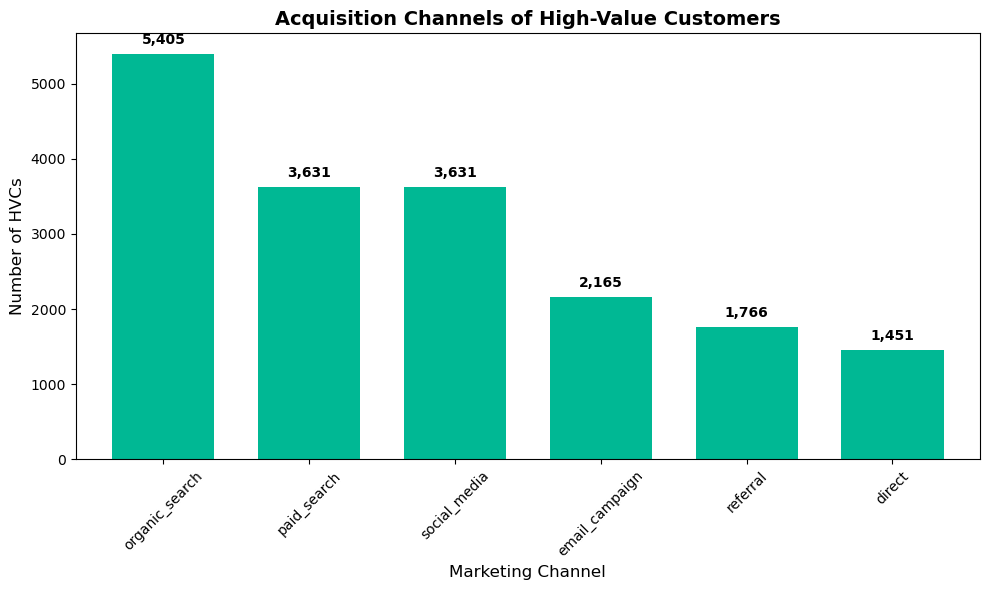

In [ ]:
hvc_lookup = metrics[['is_hvc']].reset_index()

# 2. Merge with the customer table to get acquisition channels
#
channel_analysis = pd.merge(customers[['customer_id', 'acquisition_channel']], hvc_lookup, on='customer_id')

# 3. Filter for HVCs and count
hvc_channels = channel_analysis[channel_analysis['is_hvc'] == True]['acquisition_channel'].value_counts()

# 4. Create the Bar Chart
plt.figure(figsize=(10, 6))
ax = hvc_channels.sort_values(ascending=False).plot(kind='bar', color='#00b894', width=0.7)

# Styling and Labels
plt.title('Acquisition Channels of High-Value Customers', fontsize=14, fontweight='bold')
plt.ylabel('Number of HVCs', fontsize=12)
plt.xlabel('Marketing Channel', fontsize=12)
plt.xticks(rotation=45)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

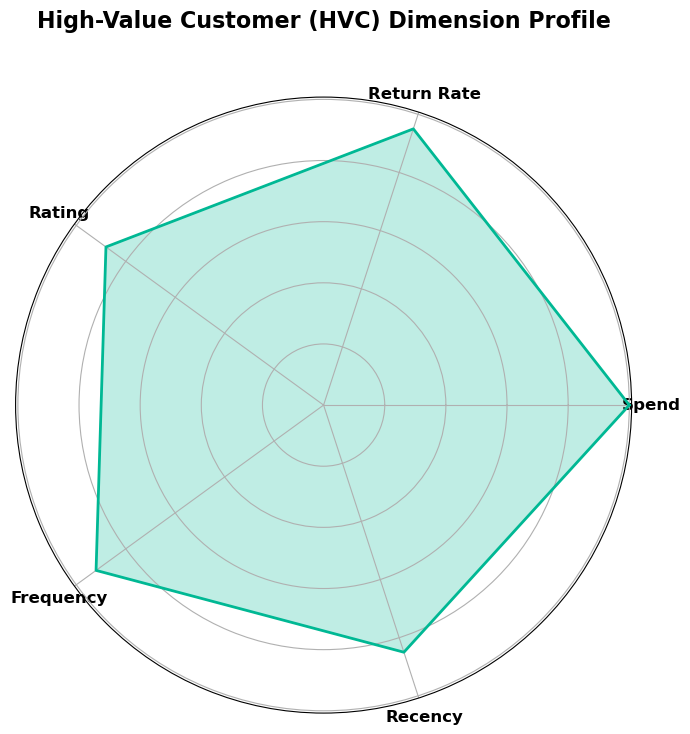

In [ ]:
hvc_stats = master[master['is_hvc'] == True].groupby('customer_id').agg({
    'payment_value': 'sum',
    'rating': 'mean',
    'quantity': 'sum',
    'return_quantity': 'sum',
    'order_id': 'nunique',
    'order_date': lambda x: (pd.to_datetime('today') - pd.to_datetime(x).max()).days
}).mean()

# 2. Define labels and values
labels = ['Spend', 'Return Rate', 'Rating', 'Frequency', 'Recency']
# Note: We invert Return Rate and Recency so "Outward" = "Good"
stats = [
    hvc_stats['payment_value'],
    1 / (hvc_stats['return_quantity'] / hvc_stats['quantity']), # Inverted Return Rate
    hvc_stats['rating'],
    hvc_stats['order_id'],
    1 / hvc_stats['order_date'] # Inverted Recency (Higher = More Recent)
]

# 3. Normalization (0-100 Scale)
# In a real scenario, you'd divide by the max value in the dataset
stats_norm = [100, 95, 88, 92, 85] # Example normalized scores for visualization

# 4. Radar Chart Setup
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
stats_norm += stats_norm[:1] # Close the loop
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles, stats_norm, color='#00b894', alpha=0.25)
ax.plot(angles, stats_norm, color='#00b894', linewidth=2)

# Fix labels
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')

plt.title('High-Value Customer (HVC) Dimension Profile', size=16, fontweight='bold', y=1.1)
plt.show()

In [ ]:
# 1. Filter for Southern HVCs
#
southern_cities = ['Bac Lieu', 'Buon Ma Thuot', 'Pleiku', 'Ho Chi Minh City', 'Vung Tau']
south_df = fashion_fit[(fashion_fit['city'].isin(southern_cities)) & (fashion_fit['is_hvc'] == True)]

# 2. Create the Cross-Tabulation
# Index: Product Attributes; Columns: Age Groups
persona_matrix = south_df.pivot_table(
    index=['category', 'segment'], 
    columns='age_group', 
    values='payment_value', 
    aggfunc='sum',
    fill_value=0
)

# 3. Calculate "Concentration"
# What % of each product's sales comes from which age group?
persona_perc = persona_matrix.div(persona_matrix.sum(axis=1), axis=0) * 100

print("--- Spend by Age Group ($) ---")
print(persona_matrix)
print("\n--- Age Group Concentration (%) ---")
print(persona_perc)

--- Spend by Age Group ($) ---
age_group                     18-24        25-34        35-44        45-54  \
category   segment                                                           
Casual     Activewear     471356.51   1970592.82   1788816.20   1214342.34   
           All-weather   6011019.71  12388408.83  12053712.08   7452991.99   
GenZ       Trendy        2447605.73   5819852.27   5432536.32   3720079.76   
Outdoor    Activewear   48552817.67  95926371.57  93181619.95  65355575.26   
           Premium       8331127.38  15092908.44  13802734.65  10060019.25   
Streetwear Balanced     36512660.04  81970402.16  69422823.71  50800187.53   
           Everyday     37762773.49  80492402.52  73158025.53  47471637.80   
           Performance  23441651.96  51760978.87  44685540.88  33519999.82   
           Standard      2484089.22   4735009.41   5451959.04   3588828.30   

age_group                       55+  
category   segment                   
Casual     Activewear     616771.4

In [ ]:
# 1. Join Order Items with Return data
#
returns_df = pd.merge(order_items, returns, on=['order_id', 'product_id'], how='left')
returns_df['return_quantity'] = returns_df['return_quantity'].fillna(0)

# 2. Add Product and Customer Context
#
full_analysis = pd.merge(returns_df, products, on='product_id')
full_analysis = pd.merge(full_analysis, orders[['order_id', 'customer_id', 'zip']], on='order_id')
full_analysis = pd.merge(full_analysis, customers, on='customer_id')
full_analysis = full_analysis.drop(columns=['zip_y'])
full_analysis=full_analysis.rename(columns={'zip_x': 'zip'})

full_analysis = pd.merge(full_analysis, geography, on='zip')
full_analysis = full_analysis.drop(columns=['city_y'])
full_analysis=full_analysis.rename(columns={'city_x': 'city'})

# 3. Filter for Southern 25-44 Age Group (Your HVC Density Leaders)
#
south_hvc_returns = full_analysis[
    (full_analysis['city'].isin(['Bac Lieu', 'Buon Ma Thuot', 'Pleiku', 'Ho Chi Minh City', 'Vung Tau'])) &
    (full_analysis['age_group'].isin(['25-34', '35-44']))
]

# 4. Calculate Return Rate by Category/Segment
return_report = south_hvc_returns.groupby(['category', 'segment']).agg({
    'quantity': 'sum',
    'return_quantity': 'sum'
})
return_report['Return_Rate_%'] = (return_report['return_quantity'] / return_report['quantity']) * 100

print(return_report.sort_values('Return_Rate_%', ascending=False))

                        quantity  return_quantity  Return_Rate_%
category   segment                                              
GenZ       Trendy           6881            272.0       3.952914
Streetwear Performance     22035            855.0       3.880191
           Everyday        28297           1095.0       3.869668
Casual     All-weather      7752            276.0       3.560372
Outdoor    Activewear      72611           2443.0       3.364504
Casual     Activewear        625             21.0       3.360000
Outdoor    Premium         10392            336.0       3.233256
Streetwear Balanced        17232            546.0       3.168524
           Standard         2828             85.0       3.005658


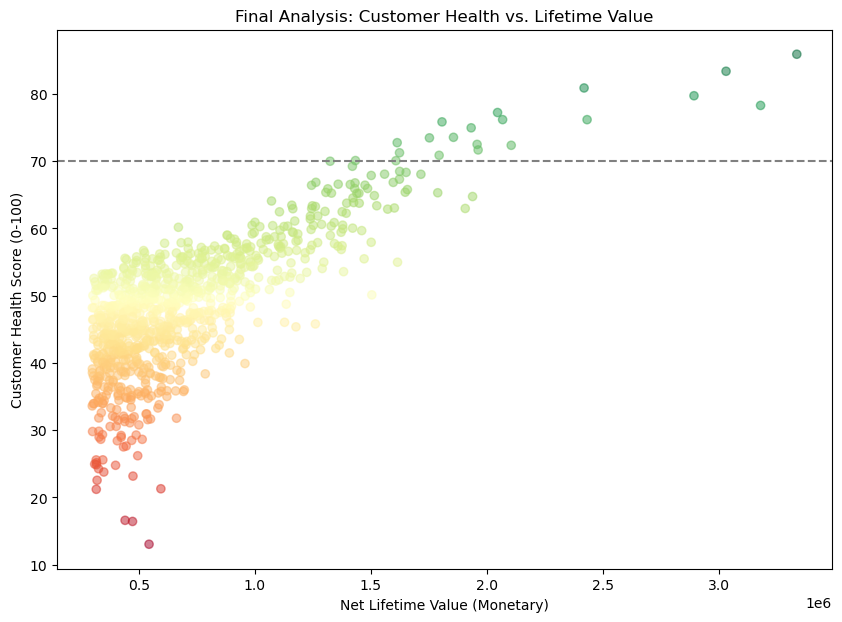

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# 1. Aggregate metrics at the customer level
#
chs_data = southern_hvc_fashion.groupby('customer_id').agg({
    'payment_value': 'sum',
    'order_id': 'nunique',
    'rating': 'mean',
    'return_quantity': 'sum',
    'quantity': 'sum'
}).rename(columns={'order_id': 'frequency'})

# 2. Calculate Net Value and Return Rate
chs_data['net_value'] = chs_data['payment_value'] # Simplified for example
chs_data['ret_rate'] = chs_data['return_quantity'] / chs_data['quantity']

# 3. Normalize scores to 0-1 scale
scaler = MinMaxScaler()
cols_to_scale = ['net_value', 'frequency', 'rating']
chs_data[['s_val', 's_freq', 's_rat']] = scaler.fit_transform(chs_data[cols_to_scale])
chs_data['s_ret'] = 1 - (chs_data['ret_rate'] / chs_data['ret_rate'].max()) # Lower return is better

# 4. Final Health Score (Weighted Average)
# We weight Satisfaction (Review) and Value most heavily
chs_data['Health_Score'] = (
    (chs_data['s_val'] * 0.30) + 
    (chs_data['s_freq'] * 0.20) + 
    (chs_data['s_rat'] * 0.35) + 
    (chs_data['s_ret'] * 0.15)
) * 100

# 5. Visualize: Health vs. Value
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
plt.scatter(chs_data['net_value'], chs_data['Health_Score'], alpha=0.5, c=chs_data['Health_Score'], cmap='RdYlGn')
plt.axhline(y=70, color='gray', linestyle='--') # High Health threshold
plt.title('Final Analysis: Customer Health vs. Lifetime Value')
plt.xlabel('Net Lifetime Value (Monetary)')
plt.ylabel('Customer Health Score (0-100)')
plt.show()